# Unsupervised Cheating Detection — Research Notebook

This notebook implements the full feature extraction pipeline with
configurable hyperparameters. It loads raw sessions from both
`normal` and `mixed` directories, extracts features, and prepares
data for unsupervised model evaluation (Isolation Forest, GMM,
One-Class SVM — added in later cells).

**Approach:** Train on normal behaviour only, detect anomalies in
mixed sessions (where cheating segments act as ground-truth anomalies).

**Leakage Prevention:**
- Session-level split: entire sessions held out (not individual chunks)
- Augmentation only on training sessions
- EDA/visualization only on training data
- Test set loaded but locked (no inspection until modeling)
- Sparse features kept (they are discriminators, not noise)

**Performance note:** Feature extraction takes time on first run.
Run once, save to disk, and reload on subsequent runs.

In [30]:
import sys
from pathlib import Path

def _find_project_root() -> Path:
    """Walk upward from cwd until we find pyproject.toml."""
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (pyproject.toml not found)")

_project_root = _find_project_root()
_src_path = _project_root / "src"
if str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from cheatdetect.data import process_sessions
from cheatdetect.preprocessing import clean_features

logging.basicConfig(level=logging.WARNING)
logging.getLogger("cheatdetect").setLevel(logging.WARNING)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [31]:
# ============================================================
# Hyperparameters
# ============================================================
CHUNK_SIZE = 50            # events per window
STEP_SIZE = 25             # slide between windows (50% overlap)
CHEATING_THRESHOLD = 0.5   # fraction of cheating events to label chunk as cheating
RANDOM_STATE = 42

# Split ratios
NORMAL_VAL_SIZE = 0.2      # 20% of normal sessions for validation
MIXED_VAL_SIZE = 0.3       # 30% of mixed sessions for validation

# Augmentation config
AUG_N_COPIES = 2           # noisy copies per raw chunk
AUG_SIGMA_MIN = 2.0        # min σ (pixels) for Gaussian noise on X,Y
AUG_SIGMA_MAX = 5.0        # max σ (pixels) — drawn uniformly per copy
AUG_ENABLED = True          # toggle augmentation on/off

NORMAL_DIR  = _project_root / "data/raw/pure normal"
MIXED_DIR   = _project_root / "data/raw/mixed"

# Processed data paths (per-split)
TRAIN_NORMAL_PATH = _project_root / "data/processed/train_normal.pkl"
VAL_NORMAL_PATH   = _project_root / "data/processed/val_normal.pkl"
VAL_MIXED_PATH    = _project_root / "data/processed/val_mixed.pkl"
TEST_MIXED_PATH   = _project_root / "data/processed/test_mixed.pkl"
SPLIT_INFO_PATH   = _project_root / "data/processed/split_info.json"

# Reports directories
REPORTS_DIR = _project_root / "reports"
EDA_DIR  = REPORTS_DIR / "eda"
VAL_DIR  = REPORTS_DIR / "val_results"
TEST_DIR = REPORTS_DIR / "test_results"
for _d in [EDA_DIR, VAL_DIR, TEST_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

In [32]:
# ============================================================
# Session-Level Split
# ============================================================
normal_files = sorted(NORMAL_DIR.glob("*.csv"))
mixed_files = sorted(MIXED_DIR.glob("*.csv"))

print(f"Total normal sessions: {len(normal_files)}")
print(f"Total mixed sessions:  {len(mixed_files)}")

# Split normal sessions: train vs val
normal_train_files, normal_val_files = train_test_split(
    normal_files,
    test_size=NORMAL_VAL_SIZE,
    random_state=RANDOM_STATE,
)

# Split mixed sessions: val vs test
mixed_val_files, mixed_test_files = train_test_split(
    mixed_files,
    test_size=1 - MIXED_VAL_SIZE,
    random_state=RANDOM_STATE,
)

print(f"\n--- Session Split ---")
print(f"Normal train: {len(normal_train_files)} sessions")
print(f"Normal val:   {len(normal_val_files)} sessions")
print(f"Mixed val:    {len(mixed_val_files)} sessions")
print(f"Mixed test:   {len(mixed_test_files)} sessions")

# Save split info for reproducibility
split_info = {
    "normal_train": [f.name for f in normal_train_files],
    "normal_val": [f.name for f in normal_val_files],
    "mixed_val": [f.name for f in mixed_val_files],
    "mixed_test": [f.name for f in mixed_test_files],
    "random_state": RANDOM_STATE,
    "normal_val_size": NORMAL_VAL_SIZE,
    "mixed_val_size": MIXED_VAL_SIZE,
}

Total normal sessions: 19
Total mixed sessions:  17

--- Session Split ---
Normal train: 15 sessions
Normal val:   4 sessions
Mixed val:    5 sessions
Mixed test:   12 sessions


In [33]:
# ============================================================
# Process Normal Train Sessions + Augmentation
# ============================================================
if TRAIN_NORMAL_PATH.exists():
    print(f"Loading cached train normal features from {TRAIN_NORMAL_PATH}")
    df_train_normal = pd.read_pickle(TRAIN_NORMAL_PATH)
else:
    print(f"Processing {len(normal_train_files)} normal train sessions...")
    train_normal_paths = [str(f) for f in normal_train_files]
    df_train_normal = process_sessions(
        train_normal_paths,
        chunk_size=CHUNK_SIZE,
        step_size=STEP_SIZE,
        cheating_threshold=CHEATING_THRESHOLD,
    )
    TRAIN_NORMAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_train_normal.to_pickle(TRAIN_NORMAL_PATH)
    print(f"Saved {len(df_train_normal)} train normal chunks to {TRAIN_NORMAL_PATH}")

print(
    f"Train normal (original): {len(df_train_normal):,} chunks  |  "
    f"cheat={df_train_normal['is_cheating'].sum()}  |  "
    f"sessions={df_train_normal['session_name'].nunique()}"
)

assert df_train_normal["is_cheating"].sum() == 0, (
    f"Unexpected cheating labels in train normal data: "
    f"{df_train_normal['is_cheating'].sum()}"
)

# Augmentation (only on train)
if AUG_ENABLED:
    aug_cache_path = _project_root / "data/processed/train_augmented.pkl"
    if aug_cache_path.exists():
        print(f"Loading cached augmented features from {aug_cache_path}")
        df_aug = pd.read_pickle(aug_cache_path)
    else:
        from cheatdetect.data import (
            augment_session_data, load_sessions, clean_session_data,
        )

        print("Generating augmented normal data (train only)...")
        sessions_raw = load_sessions(str(NORMAL_DIR))
        train_basenames = {f.name for f in normal_train_files}
        sessions_raw = {
            k: v for k, v in sessions_raw.items() if k in train_basenames
        }
        sessions_clean = {
            Path(name).stem: clean_session_data(df)
            for name, df in sessions_raw.items()
        }

        df_aug = augment_session_data(
            sessions_clean,
            chunk_size=CHUNK_SIZE,
            step_size=STEP_SIZE,
            n_copies=AUG_N_COPIES,
            sigma_range=(AUG_SIGMA_MIN, AUG_SIGMA_MAX),
            random_state=RANDOM_STATE,
        )
        df_aug.to_pickle(aug_cache_path)
        print(f"Saved {len(df_aug)} augmented chunks to {aug_cache_path}")

    print(f"Augmented chunks: {len(df_aug):,}")
    assert df_aug["is_cheating"].sum() == 0, "Augmented data leaked cheating labels"

    df_train_normal = pd.concat([df_train_normal, df_aug], ignore_index=True)

    is_aug = df_train_normal["session_name"].str.contains("_aug")
    orig_total = (~is_aug).sum()
    aug_total  = is_aug.sum()
    print(f"\n--- Post-augmentation train normal dataset ---")
    print(
        f"Original: {orig_total:,}  |  "
        f"Augmented: {aug_total:,}  |  "
        f"Combined: {len(df_train_normal):,}"
    )

    cheat_check = df_train_normal.groupby(
        df_train_normal["session_name"].str.split("_aug").str[0]
    )["is_cheating"].sum()
    assert cheat_check.sum() == 0, "Leaked cheating labels detected!"

else:
    print("Augmentation disabled — using original train normal data only.")

Loading cached train normal features from /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/train_normal.pkl
Train normal (original): 662 chunks  |  cheat=0  |  sessions=15
Loading cached augmented features from /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/train_augmented.pkl
Augmented chunks: 1,324

--- Post-augmentation train normal dataset ---
Original: 662  |  Augmented: 1,324  |  Combined: 1,986


In [34]:
# ============================================================
# Process Normal Val Sessions (no augmentation)
# ============================================================
if VAL_NORMAL_PATH.exists():
    print(f"Loading cached val normal features from {VAL_NORMAL_PATH}")
    df_val_normal = pd.read_pickle(VAL_NORMAL_PATH)
else:
    print(f"Processing {len(normal_val_files)} normal val sessions...")
    val_normal_paths = [str(f) for f in normal_val_files]
    df_val_normal = process_sessions(
        val_normal_paths,
        chunk_size=CHUNK_SIZE,
        step_size=STEP_SIZE,
        cheating_threshold=CHEATING_THRESHOLD,
    )
    df_val_normal.to_pickle(VAL_NORMAL_PATH)
    print(f"Saved {len(df_val_normal)} val normal chunks to {VAL_NORMAL_PATH}")

print(
    f"Val normal: {len(df_val_normal):,} chunks  |  "
    f"cheat={df_val_normal['is_cheating'].sum()}  |  "
    f"sessions={df_val_normal['session_name'].nunique()}"
)

assert df_val_normal["is_cheating"].sum() == 0, (
    f"Unexpected cheating labels in val normal data: "
    f"{df_val_normal['is_cheating'].sum()}"
)

Loading cached val normal features from /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/val_normal.pkl
Val normal: 197 chunks  |  cheat=0  |  sessions=4


In [35]:
# ============================================================
# Process Mixed Val Sessions
# ============================================================
if VAL_MIXED_PATH.exists():
    print(f"Loading cached val mixed features from {VAL_MIXED_PATH}")
    df_val_mixed = pd.read_pickle(VAL_MIXED_PATH)
else:
    print(f"Processing {len(mixed_val_files)} mixed val sessions...")
    val_mixed_paths = [str(f) for f in mixed_val_files]
    df_val_mixed = process_sessions(
        val_mixed_paths,
        chunk_size=CHUNK_SIZE,
        step_size=STEP_SIZE,
        cheating_threshold=CHEATING_THRESHOLD,
    )
    df_val_mixed.to_pickle(VAL_MIXED_PATH)
    print(f"Saved {len(df_val_mixed)} val mixed chunks to {VAL_MIXED_PATH}")

print(
    f"Val mixed: {len(df_val_mixed):,} chunks  |  "
    f"cheat={df_val_mixed['is_cheating'].sum():,}  |  "
    f"sessions={df_val_mixed['session_name'].nunique()}"
)

Loading cached val mixed features from /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/val_mixed.pkl
Val mixed: 196 chunks  |  cheat=82  |  sessions=5


In [36]:
# ============================================================
# Process Mixed Test Sessions (LOCKED)
# ============================================================
if TEST_MIXED_PATH.exists():
    print(f"Loading cached test mixed features from {TEST_MIXED_PATH}")
    df_test_mixed = pd.read_pickle(TEST_MIXED_PATH)
else:
    print(f"Processing {len(mixed_test_files)} mixed test sessions...")
    test_mixed_paths = [str(f) for f in mixed_test_files]
    df_test_mixed = process_sessions(
        test_mixed_paths,
        chunk_size=CHUNK_SIZE,
        step_size=STEP_SIZE,
        cheating_threshold=CHEATING_THRESHOLD,
    )
    df_test_mixed.to_pickle(TEST_MIXED_PATH)
    print(f"Saved {len(df_test_mixed)} test mixed chunks to {TEST_MIXED_PATH}")

print(
    f"Test mixed: {len(df_test_mixed):,} chunks  |  "
    f"cheat={df_test_mixed['is_cheating'].sum():,}  |  "
    f"sessions={df_test_mixed['session_name'].nunique()}"
)

print("\n⚠️  Test set loaded but LOCKED — no inspection until modeling phase.")

Loading cached test mixed features from /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/test_mixed.pkl
Test mixed: 366 chunks  |  cheat=205  |  sessions=10

⚠️  Test set loaded but LOCKED — no inspection until modeling phase.


In [37]:
# ============================================================
# Dataset Summary
# ============================================================
summary_data = {
    "Train Normal": {
        "chunks": len(df_train_normal),
        "cheat": int(df_train_normal["is_cheating"].sum()),
        "sessions": df_train_normal["session_name"].nunique(),
    },
    "Val Normal": {
        "chunks": len(df_val_normal),
        "cheat": int(df_val_normal["is_cheating"].sum()),
        "sessions": df_val_normal["session_name"].nunique(),
    },
    "Val Mixed": {
        "chunks": len(df_val_mixed),
        "cheat": int(df_val_mixed["is_cheating"].sum()),
        "sessions": df_val_mixed["session_name"].nunique(),
    },
    "Test Mixed (LOCKED)": {
        "chunks": len(df_test_mixed),
        "cheat": int(df_test_mixed["is_cheating"].sum()),
        "sessions": df_test_mixed["session_name"].nunique(),
    },
}

df_summary = pd.DataFrame(summary_data).T
df_summary["normal"] = df_summary["chunks"] - df_summary["cheat"]
df_summary["cheat_pct"] = (df_summary["cheat"] / df_summary["chunks"] * 100).round(1)

print("=== Dataset Summary ===")
display(df_summary)

=== Dataset Summary ===


,chunks,cheat,sessions,normal,cheat_pct
Train Normal,1986,0,1339,1986,0.0
Val Normal,197,0,4,197,0.0
Val Mixed,196,82,5,114,41.8
Test Mixed (LOCKED),366,205,10,161,56.0


In [38]:
# ============================================================
# Feature Merging
# ============================================================
# Merge redundant action events that signal the same behavior:
# blur + focus + tab_switch → window_switch_events
# All three indicate "student left the exam window."

def merge_window_switch_events(df: pd.DataFrame) -> pd.DataFrame:
    """Merge blur, focus, and tab_switch events into window_switch_events."""
    df = df.copy()
    cols_available = [c for c in ["blur_events", "focus_events", "tab_switch_events"]
                      if c in df.columns]
    if len(cols_available) >= 2:
        df["window_switch_events"] = df[cols_available].sum(axis=1)
        for col in cols_available:
            df.drop(columns=[col], inplace=True)
    elif len(cols_available) == 1:
        df["window_switch_events"] = df[cols_available[0]]
        df.drop(columns=cols_available, inplace=True)
    return df

df_train_normal = merge_window_switch_events(df_train_normal)
df_val_normal   = merge_window_switch_events(df_val_normal)
df_val_mixed    = merge_window_switch_events(df_val_mixed)
df_test_mixed   = merge_window_switch_events(df_test_mixed)

print("Merged blur_events + focus_events + tab_switch_events → window_switch_events")
print(f"Features after merge: {df_train_normal.shape[1] - 2} (excl. is_cheating & session_name)")

Merged blur_events + focus_events + tab_switch_events → window_switch_events
Features after merge: 32 (excl. is_cheating & session_name)


In [39]:
# ============================================================
# EDA: Zero-Variance Feature Detection (Train Normal Only)
# ============================================================
X_train_raw, feature_names_raw = clean_features(df_train_normal)

# Only drop features with literally zero variance
zero_variance = X_train_raw.var() == 0
features_to_drop_zero_var = X_train_raw.columns[zero_variance].tolist()

print("=== Zero-Variance Features (variance == 0) ===")
if len(features_to_drop_zero_var) > 0:
    print(f"Found {len(features_to_drop_zero_var)} zero-variance features:")
    for feat in features_to_drop_zero_var:
        print(f"  - {feat}")
else:
    print("No zero-variance features found.")

print(f"\nTotal features before filtering: {len(feature_names_raw)}")

# Remove zero-variance features for visualization
X_train_viz = X_train_raw.drop(columns=features_to_drop_zero_var, errors="ignore")
feature_names_viz = [f for f in feature_names_raw if f not in features_to_drop_zero_var]

print(f"Features for visualization: {len(feature_names_viz)}")

=== Zero-Variance Features (variance == 0) ===
No zero-variance features found.

Total features before filtering: 32
Features for visualization: 32


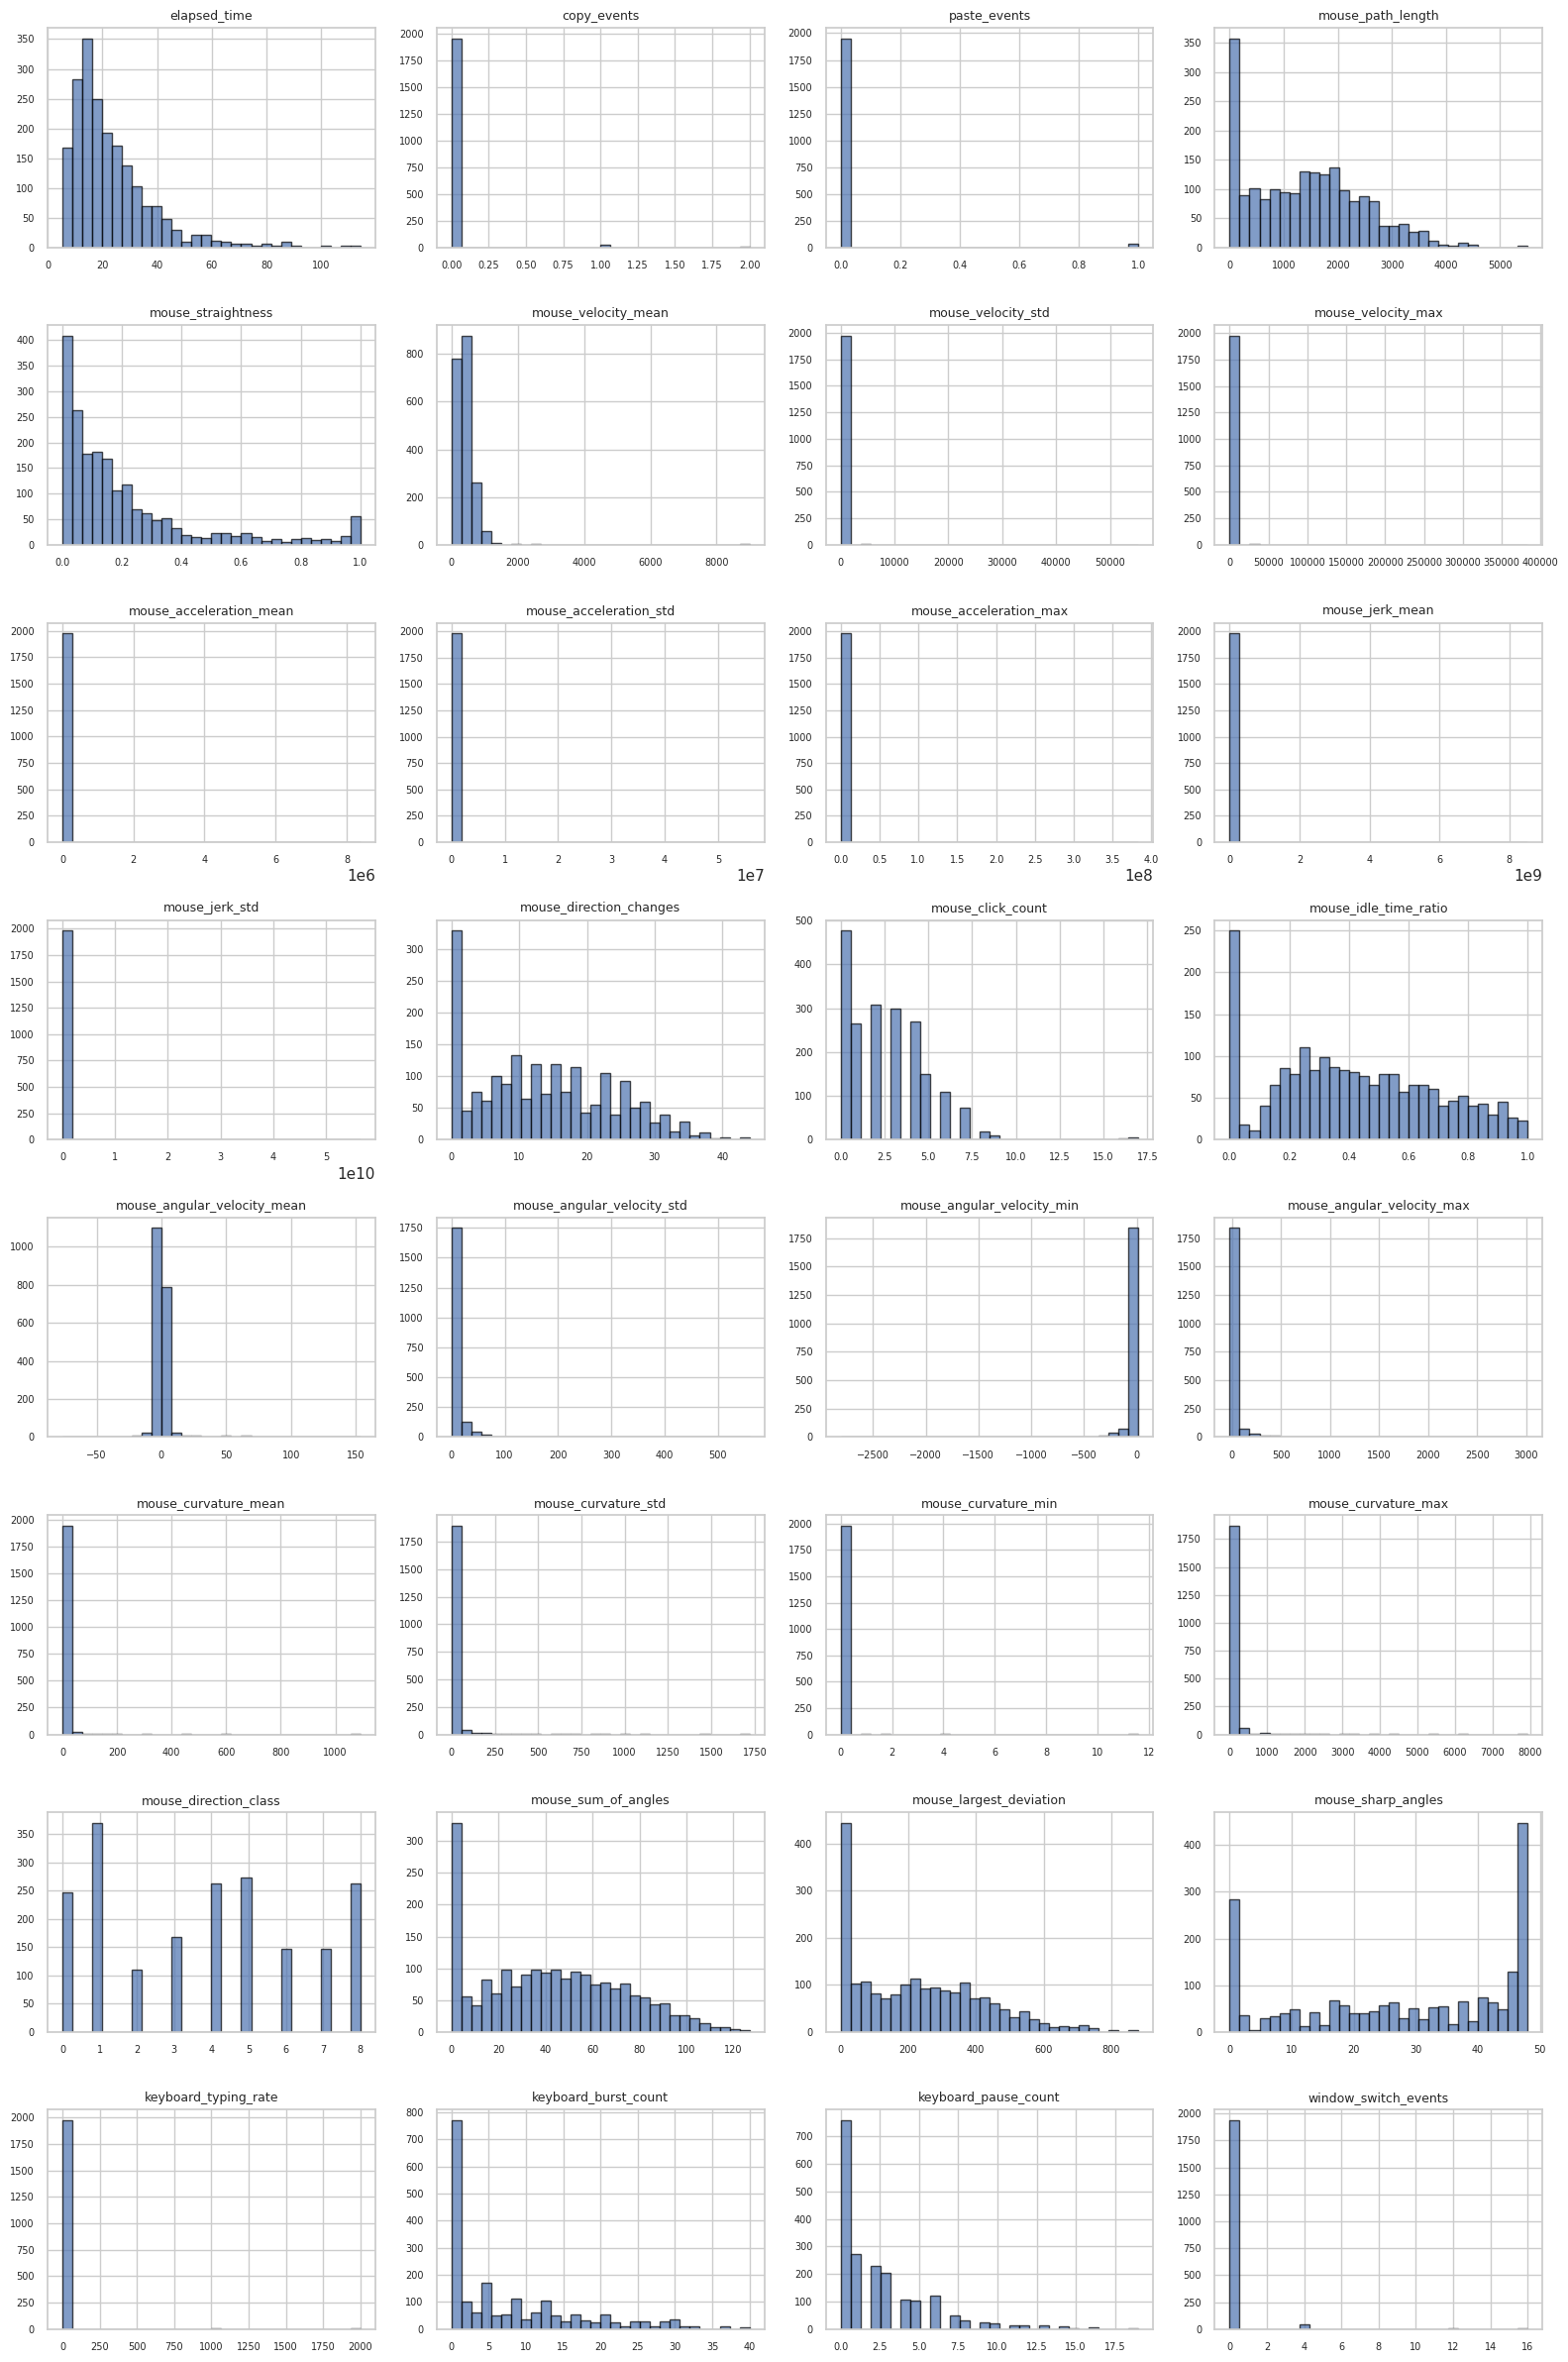

Note: Sparse features (e.g. copy_events, window_switch_events) are normal.
They are valuable discriminators for anomaly detection — not noise.


In [40]:
# ============================================================
# EDA: Feature Distributions (Train Normal Only)
# ============================================================
n_features = len(feature_names_viz)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(feature_names_viz):
    if i >= len(axes):
        break
    vals = X_train_viz[feat].dropna()
    axes[i].hist(vals, bins=30, alpha=0.7, edgecolor="black")
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(EDA_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: Sparse features (e.g. copy_events, window_switch_events) are normal.")
print("They are valuable discriminators for anomaly detection — not noise.")

=== Highly Correlated Pairs (|r| > 0.85) ===
Found 28 pairs



,feature_1,feature_2,correlation,tier
0,mouse_acceleration_std,mouse_acceleration_max,0.999958,Tier 1 (drop)
1,mouse_jerk_mean,mouse_jerk_std,0.999906,Tier 1 (drop)
2,mouse_acceleration_mean,mouse_acceleration_std,0.999580,Tier 1 (drop)
3,mouse_acceleration_mean,mouse_acceleration_max,0.999324,Tier 1 (drop)
4,mouse_acceleration_std,mouse_jerk_std,0.998852,Tier 2 (keep)
5,mouse_acceleration_max,mouse_jerk_std,0.998808,Tier 2 (keep)
6,mouse_acceleration_std,mouse_jerk_mean,0.998761,Tier 2 (keep)
7,mouse_acceleration_max,mouse_jerk_mean,0.998613,Tier 2 (keep)
8,mouse_acceleration_mean,mouse_jerk_mean,0.998503,Tier 2 (keep)
9,mouse_acceleration_mean,mouse_jerk_std,0.998261,Tier 2 (keep)



=== Tier 1 Features to Drop ===
Dropping 7 redundant features:
  - mouse_acceleration_max
  - mouse_acceleration_std
  - mouse_angular_velocity_max
  - mouse_curvature_max
  - mouse_jerk_std
  - mouse_velocity_max
  - mouse_velocity_std


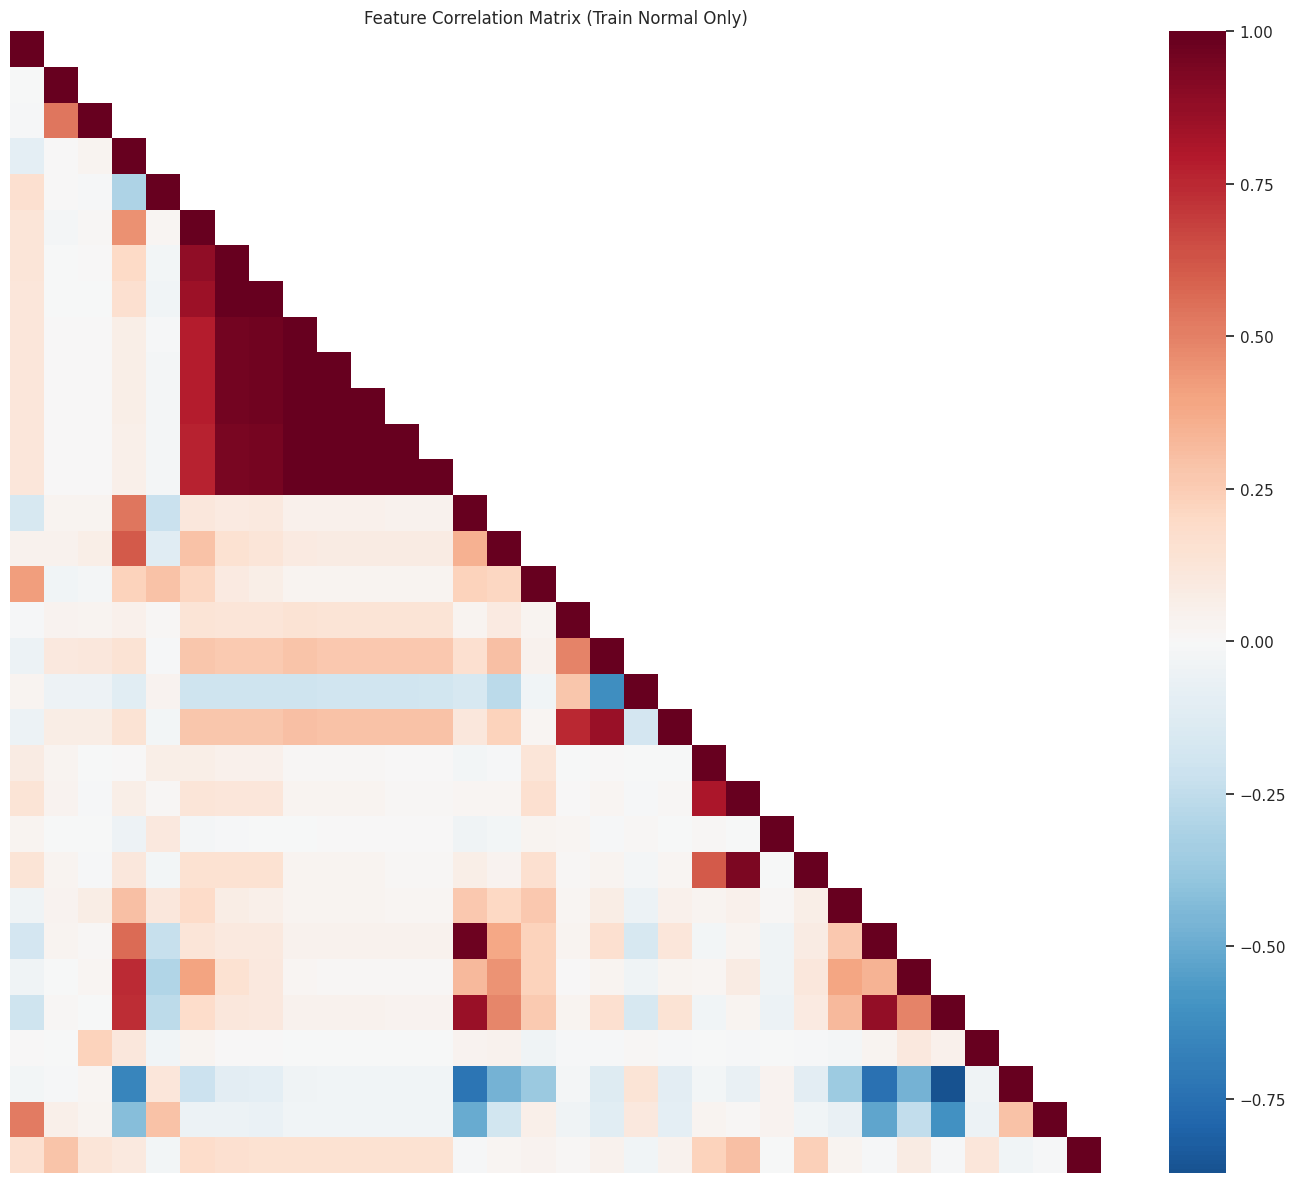

In [41]:
# ============================================================
# EDA: Correlation Analysis with Tiered Classification
# ============================================================
corr = X_train_viz.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Find highly correlated pairs
HIGH_CORR_THRESHOLD = 0.85
high_corr = np.where(np.abs(corr.values) > HIGH_CORR_THRESHOLD)
pairs = [
    (feature_names_viz[i], feature_names_viz[j], float(corr.iloc[i, j]))
    for i, j in zip(*high_corr) if i < j
]

print(f"=== Highly Correlated Pairs (|r| > {HIGH_CORR_THRESHOLD}) ===")
print(f"Found {len(pairs)} pairs\n")

def classify_correlation_pair(feat1: str, feat2: str) -> str:
    """
    Classify a correlated pair into Tier 1 (drop) or Tier 2 (keep).
    
    Tier 1: Same signal, different aggregation (e.g., mean vs max of same feature)
    Tier 2: Derived but different signal (e.g., velocity vs acceleration)
    """
    def _get_base_name(feat: str) -> str:
        for suffix in ["_mean", "_std", "_max", "_min", "_sum"]:
            if feat.endswith(suffix):
                return feat[:-len(suffix)]
        return feat

    base1 = _get_base_name(feat1)
    base2 = _get_base_name(feat2)

    if base1 == base2:
        return "Tier 1 (drop)"

    return "Tier 2 (keep)"

pair_classifications = []
for feat1, feat2, r_val in sorted(pairs, key=lambda x: -abs(x[2])):
    tier = classify_correlation_pair(feat1, feat2)
    pair_classifications.append({
        "feature_1": feat1,
        "feature_2": feat2,
        "correlation": r_val,
        "tier": tier,
    })

df_pairs = pd.DataFrame(pair_classifications)

if len(df_pairs) > 0:
    display(df_pairs)

    tier1_pairs = df_pairs[df_pairs["tier"] == "Tier 1 (drop)"]

    features_to_drop_tier1 = set()
    for _, row in tier1_pairs.iterrows():
        feat1, feat2 = row["feature_1"], row["feature_2"]

        if feat1.endswith("_max") or feat1.endswith("_min"):
            features_to_drop_tier1.add(feat1)
        elif feat2.endswith("_max") or feat2.endswith("_min"):
            features_to_drop_tier1.add(feat2)
        elif feat1.endswith("_std") and not feat2.endswith("_mean"):
            features_to_drop_tier1.add(feat1)
        elif feat2.endswith("_std") and not feat1.endswith("_mean"):
            features_to_drop_tier1.add(feat2)
        else:
            features_to_drop_tier1.add(feat2)

    features_to_drop_tier1 = list(features_to_drop_tier1)

    print(f"\n=== Tier 1 Features to Drop ===")
    print(f"Dropping {len(features_to_drop_tier1)} redundant features:")
    for feat in sorted(features_to_drop_tier1):
        print(f"  - {feat}")
else:
    features_to_drop_tier1 = []
    print("No highly correlated pairs found.")

# Correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", center=0,
    xticklabels=False, yticklabels=False,
)
plt.title("Feature Correlation Matrix (Train Normal Only)")
plt.tight_layout()
plt.savefig(EDA_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# ============================================================
# EDA: Feature Summary & Keep/Drop Decisions
# ============================================================
all_features_to_drop = set(features_to_drop_zero_var) | set(features_to_drop_tier1)

feature_summary = pd.DataFrame({
    "feature": feature_names_raw,
    "variance": X_train_raw.var().values,
    "zero_variance": [f in features_to_drop_zero_var for f in feature_names_raw],
    "tier1_redundant": [f in features_to_drop_tier1 for f in feature_names_raw],
    "decision": ["DROP" if f in all_features_to_drop else "KEEP" for f in feature_names_raw],
})

print("=== Feature Summary & Decisions ===")
n_total = len(feature_names_raw)
n_keep = (feature_summary["decision"] == "KEEP").sum()
n_drop = (feature_summary["decision"] == "DROP").sum()
print(f"Total features: {n_total}")
print(f"Features to KEEP: {n_keep}")
print(f"Features to DROP: {n_drop}")
print()

# Show dropped features with reasons
dropped = feature_summary[feature_summary["decision"] == "DROP"]
if len(dropped) > 0:
    print("Dropped features:")
    display(dropped[["feature", "zero_variance", "tier1_redundant"]])

# Show kept features
kept = feature_summary[feature_summary["decision"] == "KEEP"]
print(f"\nKept features ({len(kept)}):")
for feat in kept["feature"].tolist():
    print(f"  - {feat}")

=== Feature Summary & Decisions ===
Total features: 32
Features to KEEP: 25
Features to DROP: 7

Dropped features:


,feature,zero_variance,tier1_redundant
6,mouse_velocity_std,False,True
7,mouse_velocity_max,False,True
9,mouse_acceleration_std,False,True
10,mouse_acceleration_max,False,True
12,mouse_jerk_std,False,True
19,mouse_angular_velocity_max,False,True
23,mouse_curvature_max,False,True



Kept features (25):
  - elapsed_time
  - copy_events
  - paste_events
  - mouse_path_length
  - mouse_straightness
  - mouse_velocity_mean
  - mouse_acceleration_mean
  - mouse_jerk_mean
  - mouse_direction_changes
  - mouse_click_count
  - mouse_idle_time_ratio
  - mouse_angular_velocity_mean
  - mouse_angular_velocity_std
  - mouse_angular_velocity_min
  - mouse_curvature_mean
  - mouse_curvature_std
  - mouse_curvature_min
  - mouse_direction_class
  - mouse_sum_of_angles
  - mouse_largest_deviation
  - mouse_sharp_angles
  - keyboard_typing_rate
  - keyboard_burst_count
  - keyboard_pause_count
  - window_switch_events


In [43]:
# ============================================================
# Prepare Final Feature Matrices
# ============================================================
features_to_keep = kept["feature"].tolist()

print("=== Preparing Final Feature Matrices ===\n")

# Train (normal, augmented)
X_train, _ = clean_features(df_train_normal)
X_train = X_train[features_to_keep]
print(f"X_train (normal, augmented): {X_train.shape}")

# Val normal (no augmentation)
X_val_normal, _ = clean_features(df_val_normal)
X_val_normal = X_val_normal[features_to_keep]
print(f"X_val_normal:                {X_val_normal.shape}")

# Val mixed (for threshold tuning)
X_val_mixed, _ = clean_features(df_val_mixed)
X_val_mixed = X_val_mixed[features_to_keep]
y_val_mixed = df_val_mixed["is_cheating"].values
print(f"X_val_mixed:                 {X_val_mixed.shape}  |  cheat={y_val_mixed.sum()}")

# Test mixed (LOCKED)
X_test, _ = clean_features(df_test_mixed)
X_test = X_test[features_to_keep]
y_test = df_test_mixed["is_cheating"].values
print(f"X_test (LOCKED):             {X_test.shape}  |  cheat={y_test.sum()}")

print(f"\nFinal feature count: {len(features_to_keep)}")

=== Preparing Final Feature Matrices ===

X_train (normal, augmented): (1986, 25)
X_val_normal:                (197, 25)
X_val_mixed:                 (196, 25)  |  cheat=82
X_test (LOCKED):             (366, 25)  |  cheat=205

Final feature count: 25


In [44]:
# ============================================================
# Save Artifacts
# ============================================================
# Save split info
SPLIT_INFO_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(SPLIT_INFO_PATH, "w") as f:
    json.dump(split_info, f, indent=2)
print(f"Saved split info to {SPLIT_INFO_PATH}")

# Save feature lists
feature_lists = {
    "features_to_keep": features_to_keep,
    "features_to_drop_zero_var": features_to_drop_zero_var,
    "features_to_drop_tier1": features_to_drop_tier1,
    "all_features_to_drop": list(all_features_to_drop),
}

feature_lists_path = _project_root / "data/processed/feature_lists.json"
with open(feature_lists_path, "w") as f:
    json.dump(feature_lists, f, indent=2)
print(f"Saved feature lists to {feature_lists_path}")

Saved split info to /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/split_info.json
Saved feature lists to /home/amraas/projects/grad_project/llms/ai/CheatDetect/data/processed/feature_lists.json


In [45]:
# ============================================================
# Ready for Modeling
# ============================================================
print("=== Pipeline Ready ===")
print(f"Train samples:     {len(X_train):,}")
print(f"Val normal:        {len(X_val_normal):,}")
print(f"Val mixed:         {len(X_val_mixed):,}  (cheat={y_val_mixed.sum()})")
print(f"Test (LOCKED):     {len(X_test):,}  (cheat={y_test.sum()})")
print(f"Features:          {len(features_to_keep)}")
print()
print("Next: Add unsupervised models (Isolation Forest, GMM, One-Class SVM)")
print("      Use X_val_normal + X_val_mixed for threshold tuning")
print("      Use X_test for final evaluation only")

=== Pipeline Ready ===
Train samples:     1,986
Val normal:        197
Val mixed:         196  (cheat=82)
Test (LOCKED):     366  (cheat=205)
Features:          25

Next: Add unsupervised models (Isolation Forest, GMM, One-Class SVM)
      Use X_val_normal + X_val_mixed for threshold tuning
      Use X_test for final evaluation only


# Modeling: Isolation Forest + One-Class SVM + Ensemble

**Approach:**
- Train both models on normal-only data (X_train)
- **Model selection:** PR-AUC on validation data (how well does the model rank anomalies?)
- **Threshold tuning:** Recall with precision floor >= 0.5 (catch cheaters, minimize false accusations)
- **Ensemble:** Weighted average of IF and OCSVM anomaly scores
- **Final evaluation:** X_test (LOCKED until now)

**Two separate decisions:**
1. Which model/hyperparams rank anomalies best? → PR-AUC
2. Where to draw the decision boundary? → Recall with min precision

In [46]:
import warnings
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    precision_score, recall_score, f1_score, confusion_matrix,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

MODELS_DIR = _project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [47]:
# ============================================================
# Preprocessing: Skewed Features & Pipelines
# ============================================================
feature_skewness = X_train.skew()
all_non_negative = (X_train.min() >= 0)

SKEW_THRESHOLD = 2.0
skewed_features = feature_skewness[
    (feature_skewness > SKEW_THRESHOLD) & all_non_negative
].index.tolist()

print(f"=== Skewed Features (skew > {SKEW_THRESHOLD}) ===")
print(f"Features eligible for log1p: {len(skewed_features)}")
for f in skewed_features:
    print(f"  {f}: skew={feature_skewness[f]:.1f}")
print(f"Non-skewed features: {X_train.shape[1] - len(skewed_features)}")


class Log1pSkewed(BaseEstimator, TransformerMixin):
    """Apply log1p to skewed (non-negative) features, pass through the rest."""

    def __init__(self, skewed_cols: list[str]):
        self.skewed_cols = skewed_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.skewed_cols:
            if col in X.columns:
                X[col] = np.log1p(X[col].clip(0))
        return X


if_pipeline = Pipeline([
    ("log1p", Log1pSkewed(skewed_features)),
    ("model", IsolationForest(random_state=RANDOM_STATE, n_jobs=-1)),
])

ocsvm_pipeline = Pipeline([
    ("log1p", Log1pSkewed(skewed_features)),
    ("scaler", RobustScaler()),
    ("model", OneClassSVM()),
])

print("\nIF pipeline:   log1p(skewed) → IsolationForest")
print("OCSVM pipeline: log1p(skewed) → RobustScaler → OneClassSVM")

=== Skewed Features (skew > 2.0) ===
Features eligible for log1p: 11
  elapsed_time: skew=2.1
  copy_events: skew=8.7
  paste_events: skew=7.2
  mouse_velocity_mean: skew=12.0
  mouse_acceleration_mean: skew=25.4
  mouse_angular_velocity_std: skew=8.1
  mouse_curvature_mean: skew=23.4
  mouse_curvature_std: skew=11.9
  mouse_curvature_min: skew=37.6
  keyboard_typing_rate: skew=17.4
  window_switch_events: skew=11.0
Non-skewed features: 14

IF pipeline:   log1p(skewed) → IsolationForest
OCSVM pipeline: log1p(skewed) → RobustScaler → OneClassSVM


In [48]:
# Combine validation sets for evaluation
X_val = pd.concat([X_val_normal, X_val_mixed], ignore_index=True)
y_val = np.concatenate([
    np.zeros(len(X_val_normal)),
    y_val_mixed,
])

print(f"=== Validation Set ===")
print(f"Val normal: {len(X_val_normal):,} chunks (all normal)")
print(f"Val mixed:  {len(X_val_mixed):,} chunks (cheat={y_val_mixed.sum()})")
print(f"Combined:   {len(X_val):,} chunks (cheat={y_val.sum()}, {y_val.mean()*100:.1f}%)")

=== Validation Set ===
Val normal: 197 chunks (all normal)
Val mixed:  196 chunks (cheat=82)
Combined:   393 chunks (cheat=82.0, 20.9%)


In [49]:
# ============================================================
# Isolation Forest — Grid Search (PR-AUC on val)
# ============================================================
IF_PARAM_GRID = {
    "model__n_estimators": [100, 200, 300],
    "model__max_samples": [256, 0.8, "auto"],
    "model__contamination": [0.01, 0.05, 0.1],
}

print("=== Isolation Forest Grid Search ===")
if_results = []

for params in ParameterGrid(IF_PARAM_GRID):
    if_pipeline.set_params(**params)
    if_pipeline.fit(X_train)
    anomaly_scores = -if_pipeline.decision_function(X_val)
    pr_auc = average_precision_score(y_val, anomaly_scores)
    if_results.append({**params, "pr_auc": pr_auc})

df_if_results = pd.DataFrame(if_results).sort_values("pr_auc", ascending=False)

print(f"Configs tried: {len(df_if_results)}")
print("\nTop 5 IF configs by PR-AUC:")
display(df_if_results.head(5))

best_if_config = df_if_results.iloc[0]
print(f"\nBest IF config: n_estimators={best_if_config['model__n_estimators']}, "
      f"max_samples={best_if_config['model__max_samples']}, "
      f"contamination={best_if_config['model__contamination']}, "
      f"PR-AUC={best_if_config['pr_auc']:.4f}")

# Train best IF
if_pipeline.set_params(
    model__n_estimators=int(best_if_config["model__n_estimators"]),
    model__max_samples=best_if_config["model__max_samples"],
    model__contamination=best_if_config["model__contamination"],
)
if_pipeline.fit(X_train)
if_scores_val = -if_pipeline.decision_function(X_val)
if_scores_test = -if_pipeline.decision_function(X_test)

=== Isolation Forest Grid Search ===
Configs tried: 27

Top 5 IF configs by PR-AUC:


,model__contamination,model__max_samples,model__n_estimators,pr_auc
5,0.01,0.8,300,0.621471
23,0.10,0.8,300,0.621471
14,0.05,0.8,300,0.621471
12,0.05,0.8,100,0.620302
21,0.10,0.8,100,0.620302



Best IF config: n_estimators=300, max_samples=0.8, contamination=0.01, PR-AUC=0.6215


In [50]:
# ============================================================
# One-Class SVM — Grid Search (PR-AUC on val)
# ============================================================
OCSVM_PARAM_GRID = {
    "model__nu": [0.01, 0.05, 0.1],
    "model__gamma": ["scale", "auto", 0.1, 0.01],
    "model__kernel": ["rbf"],
}

print("=== One-Class SVM Grid Search ===")
ocsvm_results = []

for params in ParameterGrid(OCSVM_PARAM_GRID):
    ocsvm_pipeline.set_params(**params)
    ocsvm_pipeline.fit(X_train)
    anomaly_scores = -ocsvm_pipeline.decision_function(X_val)
    pr_auc = average_precision_score(y_val, anomaly_scores)
    ocsvm_results.append({**params, "pr_auc": pr_auc})

df_ocsvm_results = pd.DataFrame(ocsvm_results).sort_values("pr_auc", ascending=False)

print(f"Configs tried: {len(df_ocsvm_results)}")
print("\nTop 5 OCSVM configs by PR-AUC:")
display(df_ocsvm_results.head(5))

best_ocsvm_config = df_ocsvm_results.iloc[0]
print(f"\nBest OCSVM config: nu={best_ocsvm_config['model__nu']}, "
      f"gamma={best_ocsvm_config['model__gamma']}, "
      f"PR-AUC={best_ocsvm_config['pr_auc']:.4f}")

# Train best OCSVM
ocsvm_pipeline.set_params(
    model__nu=best_ocsvm_config["model__nu"],
    model__gamma=best_ocsvm_config["model__gamma"],
    model__kernel=best_ocsvm_config["model__kernel"],
)
ocsvm_pipeline.fit(X_train)
ocsvm_scores_val = -ocsvm_pipeline.decision_function(X_val)
ocsvm_scores_test = -ocsvm_pipeline.decision_function(X_test)

=== One-Class SVM Grid Search ===
Configs tried: 12

Top 5 OCSVM configs by PR-AUC:


,model__gamma,model__kernel,model__nu,pr_auc
7,0.1,rbf,0.05,0.232719
6,0.1,rbf,0.01,0.232699
8,0.1,rbf,0.10,0.232678
3,auto,rbf,0.01,0.214624
5,auto,rbf,0.10,0.214480



Best OCSVM config: nu=0.05, gamma=0.1, PR-AUC=0.2327


In [51]:
# ============================================================
# Ensemble — Combine IF + OCSVM Scores
# ============================================================
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    s_min, s_max = scores.min(), scores.max()
    if s_max > s_min:
        return (scores - s_min) / (s_max - s_min)
    return np.zeros_like(scores)

if_norm_val = normalize_scores(if_scores_val)
ocsvm_norm_val = normalize_scores(ocsvm_scores_val)

print("=== Ensemble Grid Search (weights) ===")
ENSEMBLE_WEIGHTS = [0.3, 0.5, 0.7]
ensemble_results = []

for w in ENSEMBLE_WEIGHTS:
    ensemble_scores = w * if_norm_val + (1 - w) * ocsvm_norm_val
    pr_auc = average_precision_score(y_val, ensemble_scores)
    ensemble_results.append({"if_weight": w, "ocsvm_weight": 1 - w, "pr_auc": pr_auc})

df_ensemble_results = pd.DataFrame(ensemble_results).sort_values("pr_auc", ascending=False)
display(df_ensemble_results)

best_ensemble = df_ensemble_results.iloc[0]
best_w = best_ensemble["if_weight"]
print(f"\nBest ensemble weight: IF={best_w:.1f}, OCSVM={1 - best_w:.1f}, "
      f"PR-AUC={best_ensemble['pr_auc']:.4f}")

# Compute best ensemble scores for val and test
if_norm_test = normalize_scores(if_scores_test)
ocsvm_norm_test = normalize_scores(ocsvm_scores_test)

ensemble_scores_val = best_w * if_norm_val + (1 - best_w) * ocsvm_norm_val
ensemble_scores_test = best_w * if_norm_test + (1 - best_w) * ocsvm_norm_test

=== Ensemble Grid Search (weights) ===


,if_weight,ocsvm_weight,pr_auc
2,0.7,0.3,0.515737
1,0.5,0.5,0.369201
0,0.3,0.7,0.308941



Best ensemble weight: IF=0.7, OCSVM=0.3, PR-AUC=0.5157


In [52]:
# ============================================================
# Threshold Tuning — Recall with Precision Floor >= 0.5
# ============================================================
PRECISION_FLOOR = 0.5


def tune_threshold(scores: np.ndarray, y_true: np.ndarray, label: str):
    """
    Find the threshold that maximizes recall while keeping
    precision >= PRECISION_FLOOR. Falls back to max F1 if
    no threshold meets the floor.
    """
    unique_scores = np.sort(np.unique(scores))

    best_threshold = None
    best_recall = 0
    best_precision = 0
    best_f1 = 0
    fallback_used = False

    for thr in unique_scores:
        y_pred = (scores >= thr).astype(int)
        if y_pred.sum() == 0:
            continue
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        if prec >= PRECISION_FLOOR and rec > best_recall:
            best_recall = rec
            best_precision = prec
            best_threshold = thr

    if best_threshold is None:
        fallback_used = True
        best_f1 = 0
        for thr in unique_scores:
            y_pred = (scores >= thr).astype(int)
            if y_pred.sum() == 0:
                continue
            f1 = f1_score(y_true, y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = thr
                best_recall = recall_score(y_true, y_pred, zero_division=0)
                best_precision = precision_score(y_true, y_pred, zero_division=0)

    y_final = (scores >= best_threshold).astype(int)
    final_f1 = f1_score(y_true, y_final, zero_division=0)

    print(f"\n--- {label} ---")
    if fallback_used:
        print(f"  ⚠️  No threshold met precision >= {PRECISION_FLOOR}. "
              f"Fell back to max F1.")
    print(f"  Threshold:       {best_threshold:.4f}")
    print(f"  Precision:       {best_precision:.4f}")
    print(f"  Recall:          {best_recall:.4f}")
    print(f"  F1:              {final_f1:.4f}")

    return best_threshold


print("=== Threshold Tuning (Recall with precision >= 0.5) ===")

if_threshold = tune_threshold(if_scores_val, y_val, "IF")
ocsvm_threshold = tune_threshold(ocsvm_scores_val, y_val, "OCSVM")
ensemble_threshold = tune_threshold(ensemble_scores_val, y_val, "Ensemble")

=== Threshold Tuning (Recall with precision >= 0.5) ===



--- IF ---
  Threshold:       -0.1133
  Precision:       0.5000
  Recall:          0.6585
  F1:              0.5684

--- OCSVM ---
  ⚠️  No threshold met precision >= 0.5. Fell back to max F1.
  Threshold:       -0.0817
  Precision:       0.2649
  Recall:          0.8659
  F1:              0.4057

--- Ensemble ---
  Threshold:       0.4662
  Precision:       0.5000
  Recall:          0.5000
  F1:              0.5000


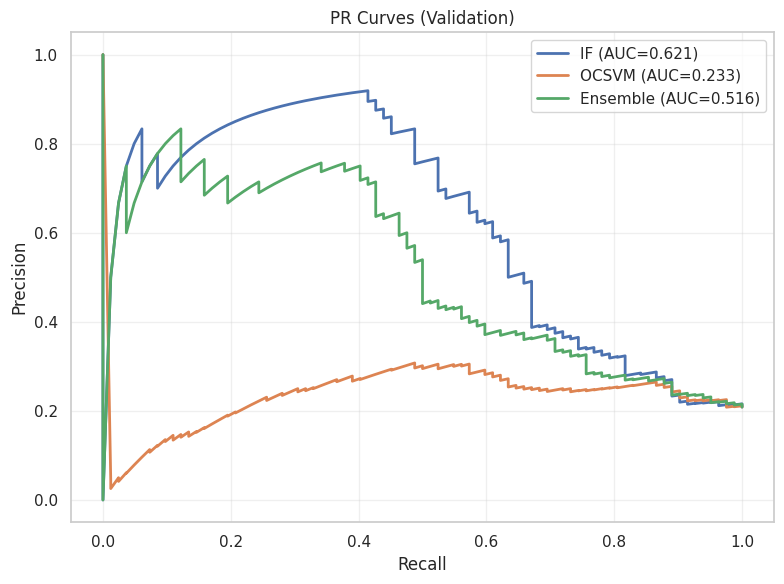

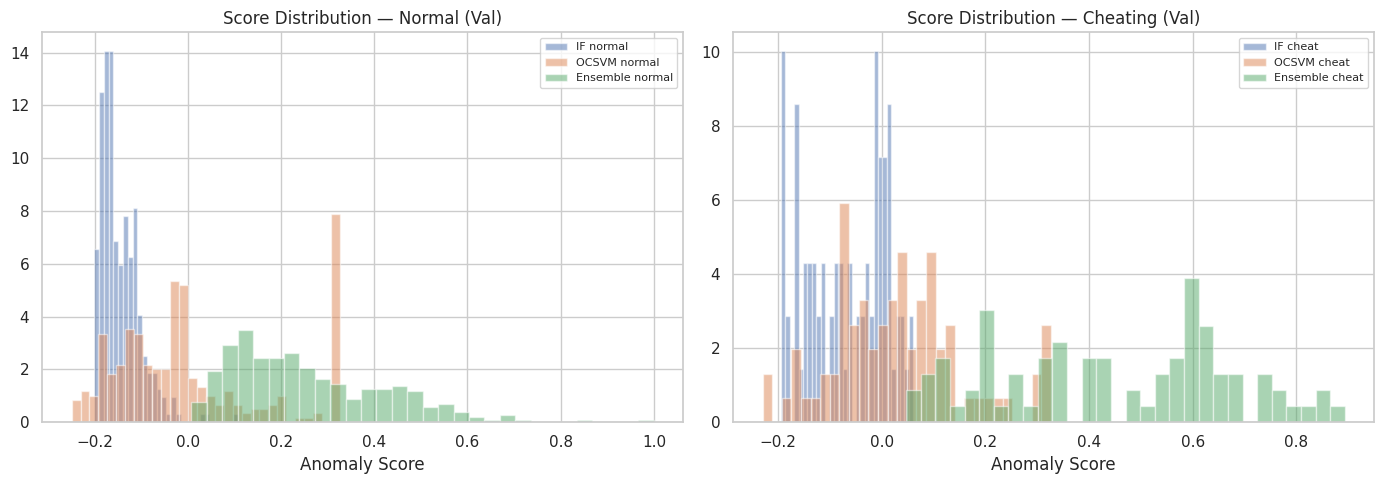

In [53]:
# ============================================================
# Validation Evaluation — PR Curves & Score Distributions
# ============================================================
models = {
    "IF": if_scores_val,
    "OCSVM": ocsvm_scores_val,
    "Ensemble": ensemble_scores_val,
}

# --- PR Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
for label, scores in models.items():
    prec, rec, _ = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    ax.plot(rec, prec, linewidth=2, label=f"{label} (AUC={pr_auc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curves (Validation)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VAL_DIR / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Score Distributions (Normal vs Cheat) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, scores in models.items():
    normal_scores = scores[y_val == 0]
    cheat_scores = scores[y_val == 1]
    axes[0].hist(normal_scores, bins=30, alpha=0.5, density=True, label=f"{label} normal")
    axes[1].hist(cheat_scores, bins=30, alpha=0.5, density=True, label=f"{label} cheat")
axes[0].set_title("Score Distribution — Normal (Val)")
axes[0].legend(fontsize=8)
axes[0].set_xlabel("Anomaly Score")
axes[1].set_title("Score Distribution — Cheating (Val)")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Anomaly Score")
plt.tight_layout()
plt.savefig(VAL_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

FINAL EVALUATION — Test Set

--- IF ---
  PR-AUC:   0.7578
  ROC-AUC:  0.7206
  Precision: 0.7514
  Recall:    0.6634
  F1:        0.7047

--- OCSVM ---
  PR-AUC:   0.6227
  ROC-AUC:  0.6245
  Precision: 0.6213
  Recall:    0.8244
  F1:        0.7086

--- Ensemble ---
  PR-AUC:   0.7483
  ROC-AUC:  0.7133
  Precision: 0.8013
  Recall:    0.6098
  F1:        0.6925

=== Test Results Summary ===


,pr_auc,roc_auc,precision,recall,f1,threshold,tp,tn,fp,fn,cm,scores
model,,,,,,,,,,,,
IF,0.757755,0.720557,0.751381,0.663415,0.704663,-0.113270,136,116,45,69,"[[116, 45], [69, 136]]","[0.0271511058880467, -0.009880708537019944, -0..."
OCSVM,0.622660,0.624542,0.621324,0.824390,0.708595,-0.081718,169,58,103,36,"[[58, 103], [36, 169]]","[0.32642064784061503, 0.003965940696132153, -0..."
Ensemble,0.748345,0.713286,0.801282,0.609756,0.692521,0.466203,125,130,31,80,"[[130, 31], [80, 125]]","[0.8267905142794396, 0.5784472611141369, 0.133..."


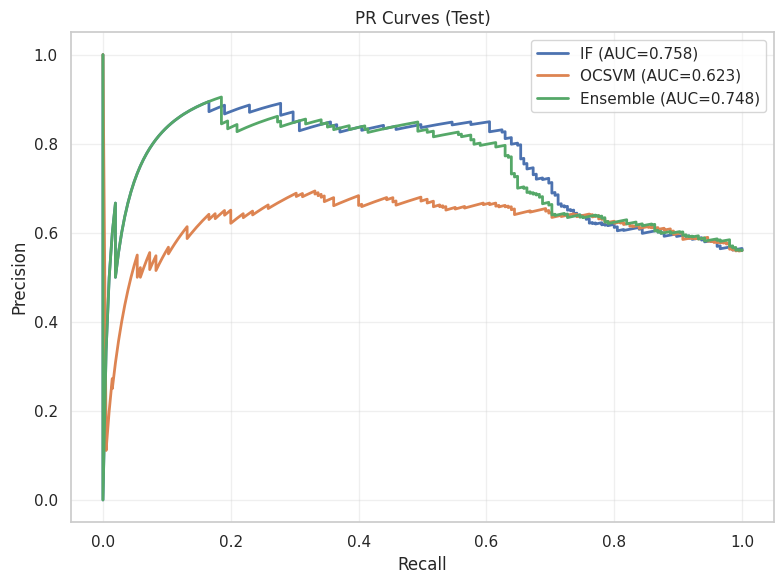

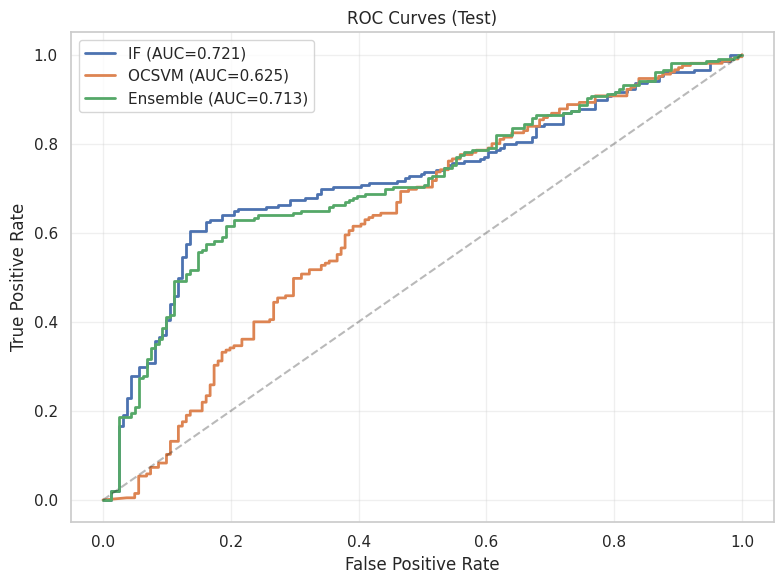

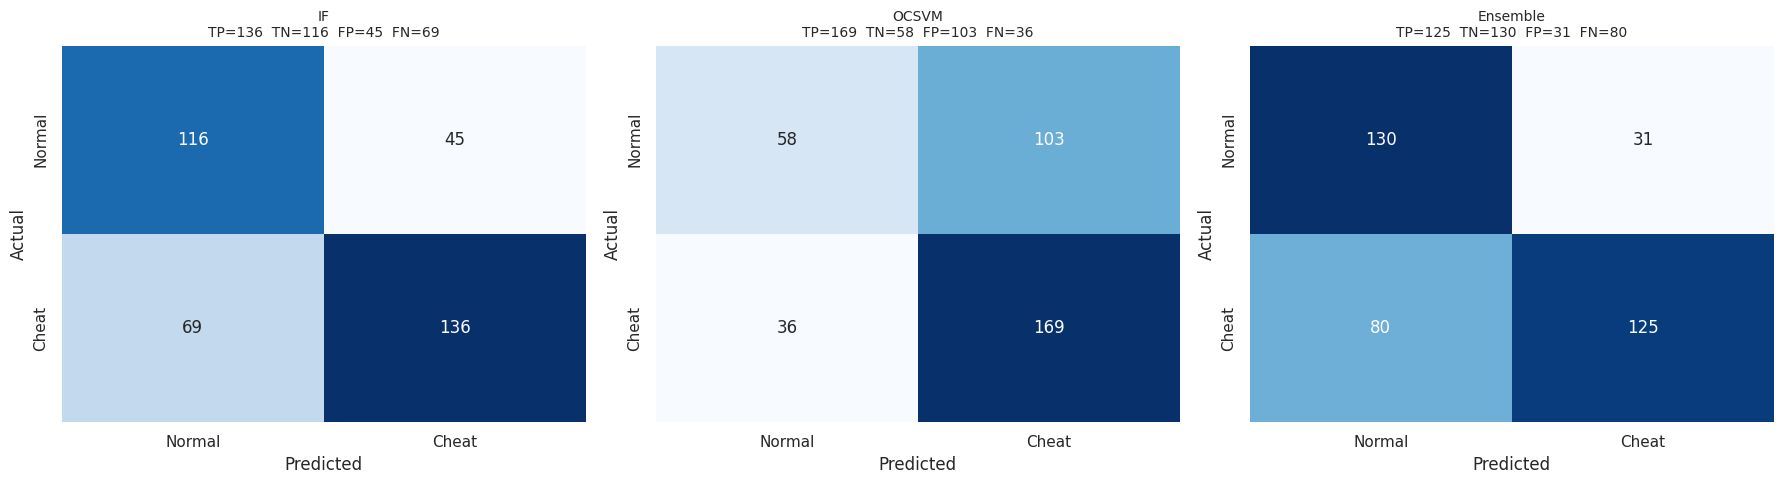

In [54]:
# ============================================================
# Final Evaluation — X_test (LOCKED until now)
# ============================================================
print("=" * 60)
print("FINAL EVALUATION — Test Set")
print("=" * 60)

def evaluate_model(name: str, scores: np.ndarray, threshold: float, y_true: np.ndarray) -> dict:
    y_pred = (scores >= threshold).astype(int)
    pr_auc = average_precision_score(y_true, scores)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n--- {name} ---")
    print(f"  PR-AUC:   {pr_auc:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")

    return {
        "model": name,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "threshold": threshold,
        "tp": int(cm[1, 1]),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "cm": cm,
        "scores": scores,
    }

test_results = [
    evaluate_model("IF", if_scores_test, if_threshold, y_test),
    evaluate_model("OCSVM", ocsvm_scores_test, ocsvm_threshold, y_test),
    evaluate_model("Ensemble", ensemble_scores_test, ensemble_threshold, y_test),
]

df_test_results = pd.DataFrame(test_results).set_index("model")
print("\n=== Test Results Summary ===")
display(df_test_results)

# --- PR Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
test_models = [
    ("IF", if_scores_test),
    ("OCSVM", ocsvm_scores_test),
    ("Ensemble", ensemble_scores_test),
]
for label, scores in test_models:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax.plot(rec, prec, linewidth=2, label=f"{label} (AUC={pr_auc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curves (Test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(TEST_DIR / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
for label, scores in test_models:
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Test)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(TEST_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, res in enumerate(test_results):
    cm = res["cm"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Cheat"],
                yticklabels=["Normal", "Cheat"],
                ax=axes[i], cbar=False)
    axes[i].set_title(f"{res['model']}\nTP={res['tp']}  TN={res['tn']}  "
                      f"FP={res['fp']}  FN={res['fn']}", fontsize=10)
    axes[i].set_ylabel("Actual")
    axes[i].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(TEST_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# ============================================================
# Save Best Model
# ============================================================
best_model_name = df_test_results["pr_auc"].idxmax()
best_pr_auc = df_test_results.loc[best_model_name, "pr_auc"]
best_threshold = df_test_results.loc[best_model_name, "threshold"]

print(f"=== Best Model: {best_model_name} (Test PR-AUC = {best_pr_auc:.4f}) ===")

if best_model_name == "IF":
    model_to_save = if_pipeline
    pipeline_name = "IsolationForest"
    base_params = best_if_config.to_dict()
elif best_model_name == "OCSVM":
    model_to_save = ocsvm_pipeline
    pipeline_name = "OneClassSVM"
    base_params = best_ocsvm_config.to_dict()
else:
    pipeline_name = "Ensemble"
    # Save both sub-models for ensemble
    # Actually, for ensemble we can't save a single pipeline.
    # We save both IF and OCSVM with the weight.
    pass

if best_model_name == "Ensemble":
    joblib.dump(if_pipeline, MODELS_DIR / "if_model.joblib")
    joblib.dump(ocsvm_pipeline, MODELS_DIR / "ocsvm_model.joblib")
    joblib.dump({
        "if_weight": best_w,
        "skewed_features": skewed_features,
        "features_to_keep": features_to_keep,
        "threshold": ensemble_threshold,
    }, MODELS_DIR / "ensemble_config.joblib")
    print(f"Saved ensemble (IF + OCSVM) + config to {MODELS_DIR}/")
else:
    joblib.dump(model_to_save, MODELS_DIR / "best_model.joblib")
    print(f"Saved {pipeline_name} to {MODELS_DIR}/best_model.joblib")

# Save preprocessing config
preprocessing_config = {
    "skewed_features": skewed_features,
    "features_to_keep": features_to_keep,
    "threshold": best_threshold,
}
joblib.dump(preprocessing_config, MODELS_DIR / "preprocessing.joblib")
print(f"Saved preprocessing config to {MODELS_DIR}/preprocessing.joblib")

# Save final config as JSON
best_params_serializable = {}
if best_model_name == "IF":
    for k, v in best_if_config.items():
        best_params_serializable[k] = str(v) if not isinstance(v, (int, float, bool, str)) else v
elif best_model_name == "OCSVM":
    for k, v in best_ocsvm_config.items():
        best_params_serializable[k] = str(v) if not isinstance(v, (int, float, bool, str)) else v

model_config = {
    "model": best_model_name,
    "pipeline": pipeline_name,
    "pr_auc_test": best_pr_auc,
    "threshold": float(best_threshold),
    "skewed_features": skewed_features,
    "features_to_keep": features_to_keep,
    "chunk_size": CHUNK_SIZE,
    "step_size": STEP_SIZE,
    "random_state": RANDOM_STATE,
}
if best_model_name != "Ensemble":
    model_config["hyperparams"] = best_params_serializable

with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print(f"Saved model config to {MODELS_DIR}/model_config.json")

print(f"\n=== All artifacts saved to {MODELS_DIR}/ ===")
for p in sorted(MODELS_DIR.iterdir()):
    print(f"  {p.name}")

=== Best Model: IF (Test PR-AUC = 0.7578) ===
Saved IsolationForest to /home/amraas/projects/grad_project/llms/ai/CheatDetect/models/best_model.joblib
Saved preprocessing config to /home/amraas/projects/grad_project/llms/ai/CheatDetect/models/preprocessing.joblib
Saved model config to /home/amraas/projects/grad_project/llms/ai/CheatDetect/models/model_config.json

=== All artifacts saved to /home/amraas/projects/grad_project/llms/ai/CheatDetect/models/ ===
  best_model.joblib
  model_config.json
  preprocessing.joblib
